In [8]:
!pip install -q supervision "ultralytics<=8.3.40"

In [9]:
# prevent ultralytics from tracking your activity
!yolo settings sync=False

JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": false,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": true,
  "wandb": false,
  "vscode_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [10]:
import cv2
import numpy as np
import supervision as sv

from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict, deque

In [5]:
from google.colab import files
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

Saving 5382495-uhd_3840_2160_24fps.mp4 to 5382495-uhd_3840_2160_24fps.mp4


In [11]:
SOURCE_VIDEO_PATH = "5382495-uhd_3840_2160_24fps.mp4"
TARGET_VIDEO_PATH = "dashcam-detections-result.mp4"

MODEL_NAME = "yolov8l.pt"
MODEL_RESOLUTION = 1280

CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5

In [12]:
model = YOLO(MODEL_NAME)

video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

print(video_info)

VideoInfo(width=3840, height=2160, fps=24.0, total_frames=818)


In [13]:
frame = next(iter(frame_generator))

result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

print(detections)

Detections(xyxy=array([[     642.84,      582.22,      802.99,      648.39],
       [     2006.6,       495.9,      2050.9,      531.64],
       [     1847.9,      497.32,      1927.1,      563.79],
       [     957.57,      1187.9,      2971.6,        1500],
       [     2037.6,      491.75,      2074.5,      526.81]], dtype=float32), mask=None, confidence=array([    0.83471,     0.83463,     0.82592,     0.63783,     0.53444], dtype=float32), class_id=array([2, 2, 2, 2, 2]), tracker_id=None, data={'class_name': array(['car', 'car', 'car', 'car', 'car'], dtype='<U3')}, metadata={})


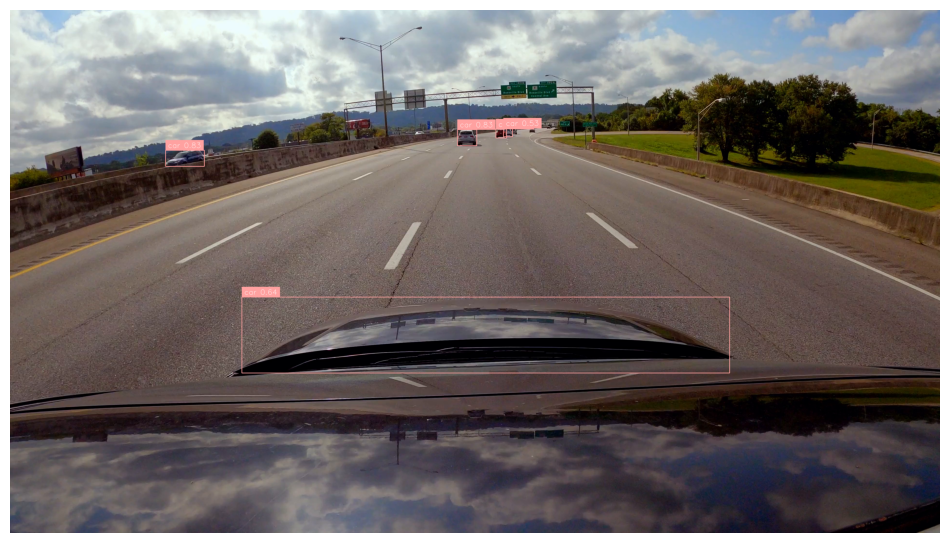

In [14]:
annotated_frame = frame.copy()

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=1)

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

sv.plot_image(annotated_frame)

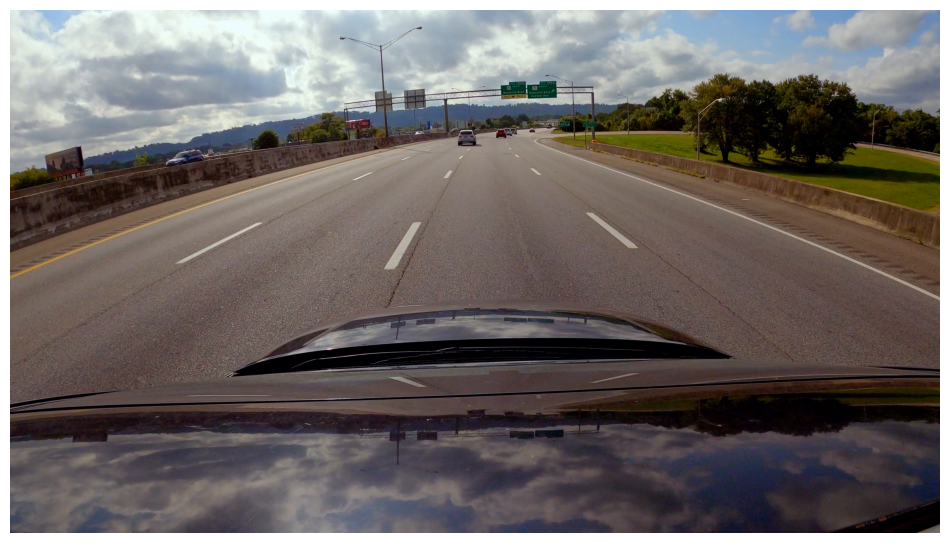

In [ ]:
sv.plot_image(frame)

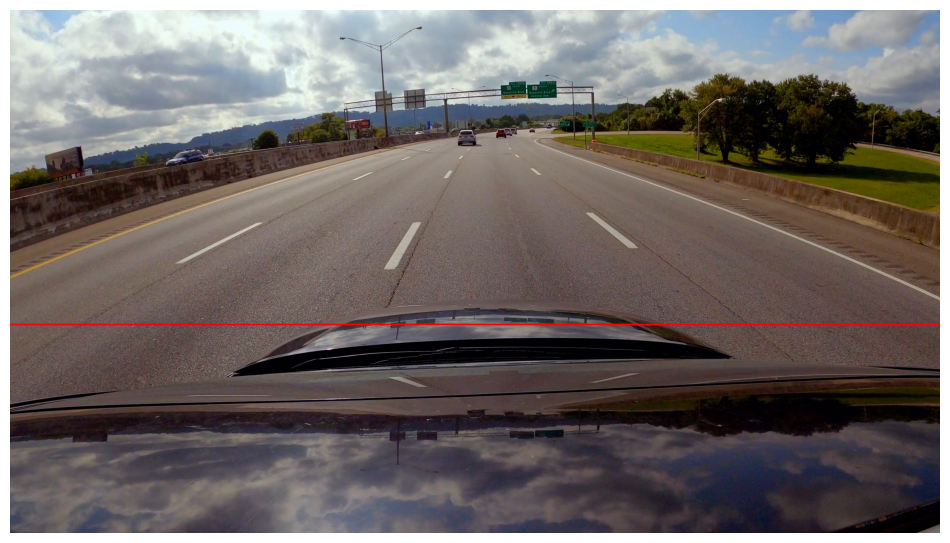

In [15]:
HOOD_Y_START = 1300  # our first guess, we'll adjust

annotated_frame = frame.copy()
cv2.line(annotated_frame, (0, HOOD_Y_START), (frame.shape[1], HOOD_Y_START), (0, 0, 255), thickness=6)
sv.plot_image(annotated_frame)

In [16]:
byte_track = sv.ByteTrack(
    frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=text_scale,
    text_thickness=thickness,
    text_position=sv.Position.BOTTOM_CENTER
)
trace_annotator = sv.TraceAnnotator(
    thickness=thickness,
    trace_length=int(video_info.fps * 2),
    position=sv.Position.BOTTOM_CENTER
)

VEHICLE_CLASS_IDS = [2, 3, 5, 7]
HOOD_Y_START = 1300

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]  # exclude own hood

        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        labels = [f"#{tracker_id} {class_name}" for tracker_id, class_name in zip(detections.tracker_id, detections['class_name'])]

        annotated_frame = frame.copy()
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

100%|██████████| 818/818 [02:57<00:00,  4.60it/s]


In [ ]:
from google.colab import files
files.download(TARGET_VIDEO_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import math

FRAME_WIDTH = video_info.width  # 3840
ASSUMED_HORIZONTAL_FOV_DEG = 100  # typical dashcam wide-angle lens, adjust if you know the real spec

focal_length_px = (FRAME_WIDTH / 2) / math.tan(math.radians(ASSUMED_HORIZONTAL_FOV_DEG / 2))
print(f"Estimated focal length: {focal_length_px:.1f} px")

Estimated focal length: 1611.1 px


In [18]:
REAL_CAR_WIDTH_M = 1.8  # average car width in meters

def estimate_distance(box_width_px, focal_length_px, real_width_m=REAL_CAR_WIDTH_M):
    if box_width_px <= 0:
        return None
    return (real_width_m * focal_length_px) / box_width_px

In [19]:
box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]  # x2 - x1
distances = [estimate_distance(w, focal_length_px) for w in box_widths]

for tracker_id, dist in zip(detections.tracker_id, distances):
    print(f"#{tracker_id}: {dist:.1f} m")

#18: 17.1 m
#66: 95.3 m
#47: 49.8 m
#103: 136.7 m


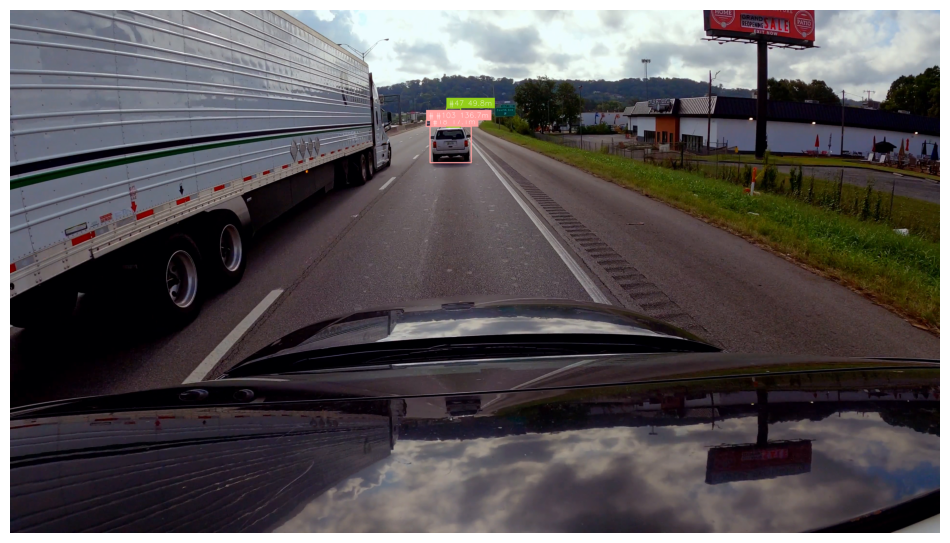

In [20]:
labels = [f"#{tid} {d:.1f}m" for tid, d in zip(detections.tracker_id, distances)]

annotated_frame = frame.copy()
annotated_frame = sv.BoxAnnotator(thickness=3).annotate(scene=annotated_frame, detections=detections)
annotated_frame = sv.LabelAnnotator(text_scale=1).annotate(scene=annotated_frame, detections=detections, labels=labels)

sv.plot_image(annotated_frame)

In [21]:
byte_track = sv.ByteTrack(
    frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=text_scale,
    text_thickness=thickness,
    text_position=sv.Position.BOTTOM_CENTER
)
trace_annotator = sv.TraceAnnotator(
    thickness=thickness,
    trace_length=int(video_info.fps * 2),
    position=sv.Position.BOTTOM_CENTER
)

VEHICLE_CLASS_IDS = [2, 3, 5, 7]
HOOD_Y_START = 1300

TARGET_VIDEO_PATH_DISTANCE = "dashcam-distance-result.mp4"

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH_DISTANCE, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]
        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        # distance estimation
        box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        distances = [estimate_distance(w, focal_length_px) for w in box_widths]

        labels = [
            f"#{tid} {dist:.1f}m" if dist is not None else f"#{tid}"
            for tid, dist in zip(detections.tracker_id, distances)
        ]

        annotated_frame = frame.copy()
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

100%|██████████| 818/818 [03:00<00:00,  4.52it/s]


In [ ]:
files.download(TARGET_VIDEO_PATH_DISTANCE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import torch

In [17]:
!pip install -q prefetch_generator yacs

lane_model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True)
lane_model.eval()

The repository hustvl_yolop does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/hustvl/yolop/zipball/main" to /root/.cache/torch/hub/main.zip


MCnet(
  (model): Sequential(
    (0): Focus(
      (conv): Conv(
        (conv): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): Hardswish()
      )
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): Hardswish()
    )
    (2): BottleneckCSP(
      (cv1): Conv(
        (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): Hardswish()
      )
      (cv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (cv3): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (cv4): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), st

In [18]:
LANE_MODEL_RESOLUTION = 960
TARGET_VIDEO_PATH_FINAL = "dashcam-final-result.mp4"

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH_FINAL, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]
        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        distances = [estimate_distance(w, focal_length_px) for w in box_widths]
        labels = [
            f"#{tid} {dist:.1f}m" if dist is not None else f"#{tid}"
            for tid, dist in zip(detections.tracker_id, distances)
        ]

        img = cv2.resize(frame, (LANE_MODEL_RESOLUTION, LANE_MODEL_RESOLUTION))
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0)

        with torch.no_grad():
            _, da_seg_out, ll_seg_out = lane_model(img_tensor)

        ll_mask = torch.argmax(ll_seg_out, dim=1).squeeze().cpu().numpy()
        da_mask = torch.argmax(da_seg_out, dim=1).squeeze().cpu().numpy()

        ll_mask_resized = cv2.resize(ll_mask.astype(np.uint8), (frame.shape[1], frame.shape[0]))
        da_mask_resized = cv2.resize(da_mask.astype(np.uint8), (frame.shape[1], frame.shape[0]))

        overlay = frame.copy()
        overlay[da_mask_resized == 1] = [255, 100, 0]
        overlay[ll_mask_resized == 1] = [0, 255, 0]

        annotated_frame = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

100%|██████████| 818/818 [31:38<00:00,  2.32s/it]


In [19]:
from google.colab import files
files.download(TARGET_VIDEO_PATH_FINAL)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check YOLOP on One Frame


In [ ]:

# ================== Working YOLOP (argmax) + hood-gap fill ==================

import torch, cv2
import numpy as np
import supervision as sv

YOLOP_SIZE = 640
HOOD_Y_START = 1300  # keep your original working cutoff

def get_both_masks(frame):
    h, w = frame.shape[:2]

    img = cv2.resize(frame, (YOLOP_SIZE, YOLOP_SIZE))
    img = img[:, :, ::-1].transpose(2, 0, 1)  # BGR->RGB, HWC->CHW
    img = np.ascontiguousarray(img)
    img_tensor = torch.from_numpy(img).float().to(device) / 255.0
    img_tensor = img_tensor.unsqueeze(0)

    with torch.no_grad():
        _, da_seg_out, ll_seg_out = yolop_model(img_tensor)

    da_mask = torch.argmax(da_seg_out, dim=1).squeeze().cpu().numpy().astype(np.uint8)
    ll_mask = torch.argmax(ll_seg_out, dim=1).squeeze().cpu().numpy().astype(np.uint8)

    da_mask = cv2.resize(da_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    ll_mask = cv2.resize(ll_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    # cut off hood area
    da_mask[HOOD_Y_START:, :] = 0
    ll_mask[HOOD_Y_START:, :] = 0

    return da_mask, ll_mask


# ================== Hood-gap fill (fills down to your real hood edge) ==================

# EDIT THESE: your calibrated (x, y) points along the top edge of the hood, left to right
HOOD_EDGE_POINTS = sorted([
    [1900, 1226],  # <-- CENTER of hood
    [1206, 1334],   # left
    [2502, 1234],  # right
    [897, 1493],     # far left
    [2980, 1423],  # far right
], key=lambda p: p[0])

def build_hood_curve(frame_width):
    xs = [p[0] for p in HOOD_EDGE_POINTS]
    ys = [p[1] for p in HOOD_EDGE_POINTS]
    all_x = np.arange(frame_width)
    hood_curve_y = np.interp(all_x, xs, ys).astype(int)
    return hood_curve_y

def fill_gap_to_hood(da_mask, hood_curve_y):
    patched = da_mask.copy()
    h, w = patched.shape

    for x in range(w):
        col = patched[:, x]
        drivable_ys = np.where(col == 1)[0]
        if len(drivable_ys) == 0:
            continue
        bottom_of_mask = drivable_ys.max()
        hood_y = hood_curve_y[x]
        if hood_y > bottom_of_mask:
            patched[bottom_of_mask:hood_y, x] = 1

    return patched


# ================== Test on a single frame ==================

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
test_frame = next(iter(frame_generator))

frame_h, frame_w = test_frame.shape[:2]
hood_curve_y = build_hood_curve(frame_width=frame_w)

da_mask, ll_mask = get_both_masks(test_frame)
da_mask = fill_gap_to_hood(da_mask, hood_curve_y)

print("Drivable area pixels:", np.sum(da_mask == 1))
print("Lane line pixels:", np.sum(ll_mask == 1))

overlay = test_frame.copy()
overlay[da_mask == 1] = (0, 255, 0)     # green = drivable area
overlay[ll_mask == 1] = (0, 255, 255)   # yellow = lane lines
result = cv2.addWeighted(overlay, 0.4, test_frame, 0.6, 0)

sv.plot_image(result)


Complete Pipeline: YOLOP + Detection/tracking/distance

In [ ]:
# ================== FULL PIPELINE: YOLOP + hood-gap fill + detection/tracking/distance ==================

import sys, torch, cv2, math
import numpy as np
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
from google.colab import files

YOLOP_SIZE = 640
HOOD_Y_START = 1300

def get_both_masks(frame):
    h, w = frame.shape[:2]

    img = cv2.resize(frame, (YOLOP_SIZE, YOLOP_SIZE))
    img = img[:, :, ::-1].transpose(2, 0, 1)
    img = np.ascontiguousarray(img)
    img_tensor = torch.from_numpy(img).float().to(device) / 255.0
    img_tensor = img_tensor.unsqueeze(0)

    with torch.no_grad():
        _, da_seg_out, ll_seg_out = yolop_model(img_tensor)

    da_mask = torch.argmax(da_seg_out, dim=1).squeeze().cpu().numpy().astype(np.uint8)
    ll_mask = torch.argmax(ll_seg_out, dim=1).squeeze().cpu().numpy().astype(np.uint8)

    da_mask = cv2.resize(da_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    ll_mask = cv2.resize(ll_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    da_mask[HOOD_Y_START:, :] = 0
    ll_mask[HOOD_Y_START:, :] = 0

    return da_mask, ll_mask


HOOD_EDGE_POINTS = sorted([
    [1900, 1226],
    [1206, 1334],
    [2502, 1234],
    [897, 1493],
    [2980, 1423],
], key=lambda p: p[0])

def build_hood_curve(frame_width):
    xs = [p[0] for p in HOOD_EDGE_POINTS]
    ys = [p[1] for p in HOOD_EDGE_POINTS]
    all_x = np.arange(frame_width)
    hood_curve_y = np.interp(all_x, xs, ys).astype(int)
    return hood_curve_y

def fill_gap_to_hood(da_mask, hood_curve_y):
    patched = da_mask.copy()
    h, w = patched.shape

    for x in range(w):
        col = patched[:, x]
        drivable_ys = np.where(col == 1)[0]
        if len(drivable_ys) == 0:
            continue
        bottom_of_mask = drivable_ys.max()
        hood_y = hood_curve_y[x]
        if hood_y > bottom_of_mask:
            patched[bottom_of_mask:hood_y, x] = 1

    return patched


def overlay_masks(frame, da_mask, ll_mask):
    overlay = frame.copy()
    overlay[da_mask == 1] = (0, 255, 0)
    overlay[ll_mask == 1] = (0, 255, 255)
    return cv2.addWeighted(overlay, 0.4, frame, 0.6, 0)


def estimate_distance(box_width_px, focal_length_px, real_width_m=1.8):
    if box_width_px <= 0:
        return None
    return (real_width_m * focal_length_px) / box_width_px


# ================== Full video processing ==================

MODEL_NAME = "yolov8l.pt"
MODEL_RESOLUTION = 1280
CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
VEHICLE_CLASS_IDS = [2, 3, 5, 7]

model = YOLO(MODEL_NAME)
video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)

byte_track = sv.ByteTrack(frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(text_scale=text_scale, text_thickness=thickness, text_position=sv.Position.BOTTOM_CENTER)
trace_annotator = sv.TraceAnnotator(thickness=thickness, trace_length=int(video_info.fps * 2), position=sv.Position.BOTTOM_CENTER)

FRAME_WIDTH = video_info.width
focal_length_px = (FRAME_WIDTH / 2) / math.tan(math.radians(50))
hood_curve_y_full = build_hood_curve(frame_width=FRAME_WIDTH)  # precomputed once, reused every frame

TARGET_VIDEO_PATH_FULL = "dashcam-full-result.mp4"
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH_FULL, video_info) as sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames):

        # detection + tracking
        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)
        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]
        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        distances = [estimate_distance(w, focal_length_px) for w in box_widths]
        labels = [f"#{tid} {d:.1f}m" if d else f"#{tid}" for tid, d in zip(detections.tracker_id, distances)]

        # lane + drivable area segmentation
        da_mask, ll_mask = get_both_masks(frame)
        da_mask = fill_gap_to_hood(da_mask, hood_curve_y_full)

        annotated_frame = overlay_masks(frame, da_mask, ll_mask)
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

files.download(TARGET_VIDEO_PATH_FULL)